# Notebook 46 — Window Size & Feature Construction Sensitivity

All outputs in `artifacts/window_sensitivity/`


In [1]:
import json,pandas as pd;from pathlib import Path;from IPython.display import Image,display
P=Path.cwd()
if P.name=='notebooks':P=P.parent
OUT=P/'artifacts'/'window_sensitivity'
print([f.name for f in sorted(OUT.iterdir())])


['feature_construction_audit.csv', 'notebook46_final_verdict.json', 'packet_count_distribution.png', 'rate_feature_comparison.csv', 'sign_reversals_by_window.png', 'window_sensitivity_dashboard.png', 'window_size_sensitivity_results.csv', 'window_size_sign_reversal_summary.csv']


## Section 1 — Window Sensitivity Results


In [2]:
display(pd.read_csv(OUT/'window_size_sensitivity_results.csv',index_col=0).round(4))


,window,n_flows,viable,pooled_auc,pooled_recall,pooled_fpr,lodo_min_auc,lodo_mean_auc,lodo_iscx,lodo_usbvpn,lodo_vnat,domain_auc,n_sign_reversals
0,5,9163,True,0.9882,0.5778,0.0000,0.3493,0.6655,0.6621,0.3493,0.9852,0.9889,15
1,10,14256,True,0.9731,0.6920,0.0006,0.1519,0.6049,0.7003,0.1519,0.9626,0.9924,14
2,20,30419,True,0.9814,0.7521,0.0005,0.2421,0.5951,0.5927,0.2421,0.9505,0.9929,18
3,30,42583,True,0.9852,0.7444,0.0005,0.2617,0.5834,0.5614,0.2617,0.9270,0.9975,19
4,50,49064,True,0.9834,0.7671,0.0014,0.2579,0.5713,0.5569,0.2579,0.8990,0.9960,19
5,100,55155,True,0.9851,0.8071,0.0021,0.2946,0.5208,0.5094,0.2946,0.7584,0.9985,20
6,200,58412,True,0.9851,0.8031,0.0017,0.3110,0.5060,0.4926,0.3110,0.7143,0.9980,20
7,300,72612,True,0.9935,0.8501,0.0012,0.4863,0.5948,0.4863,0.6121,0.6859,0.9971,16


## Section 2 — Packet Count Distribution


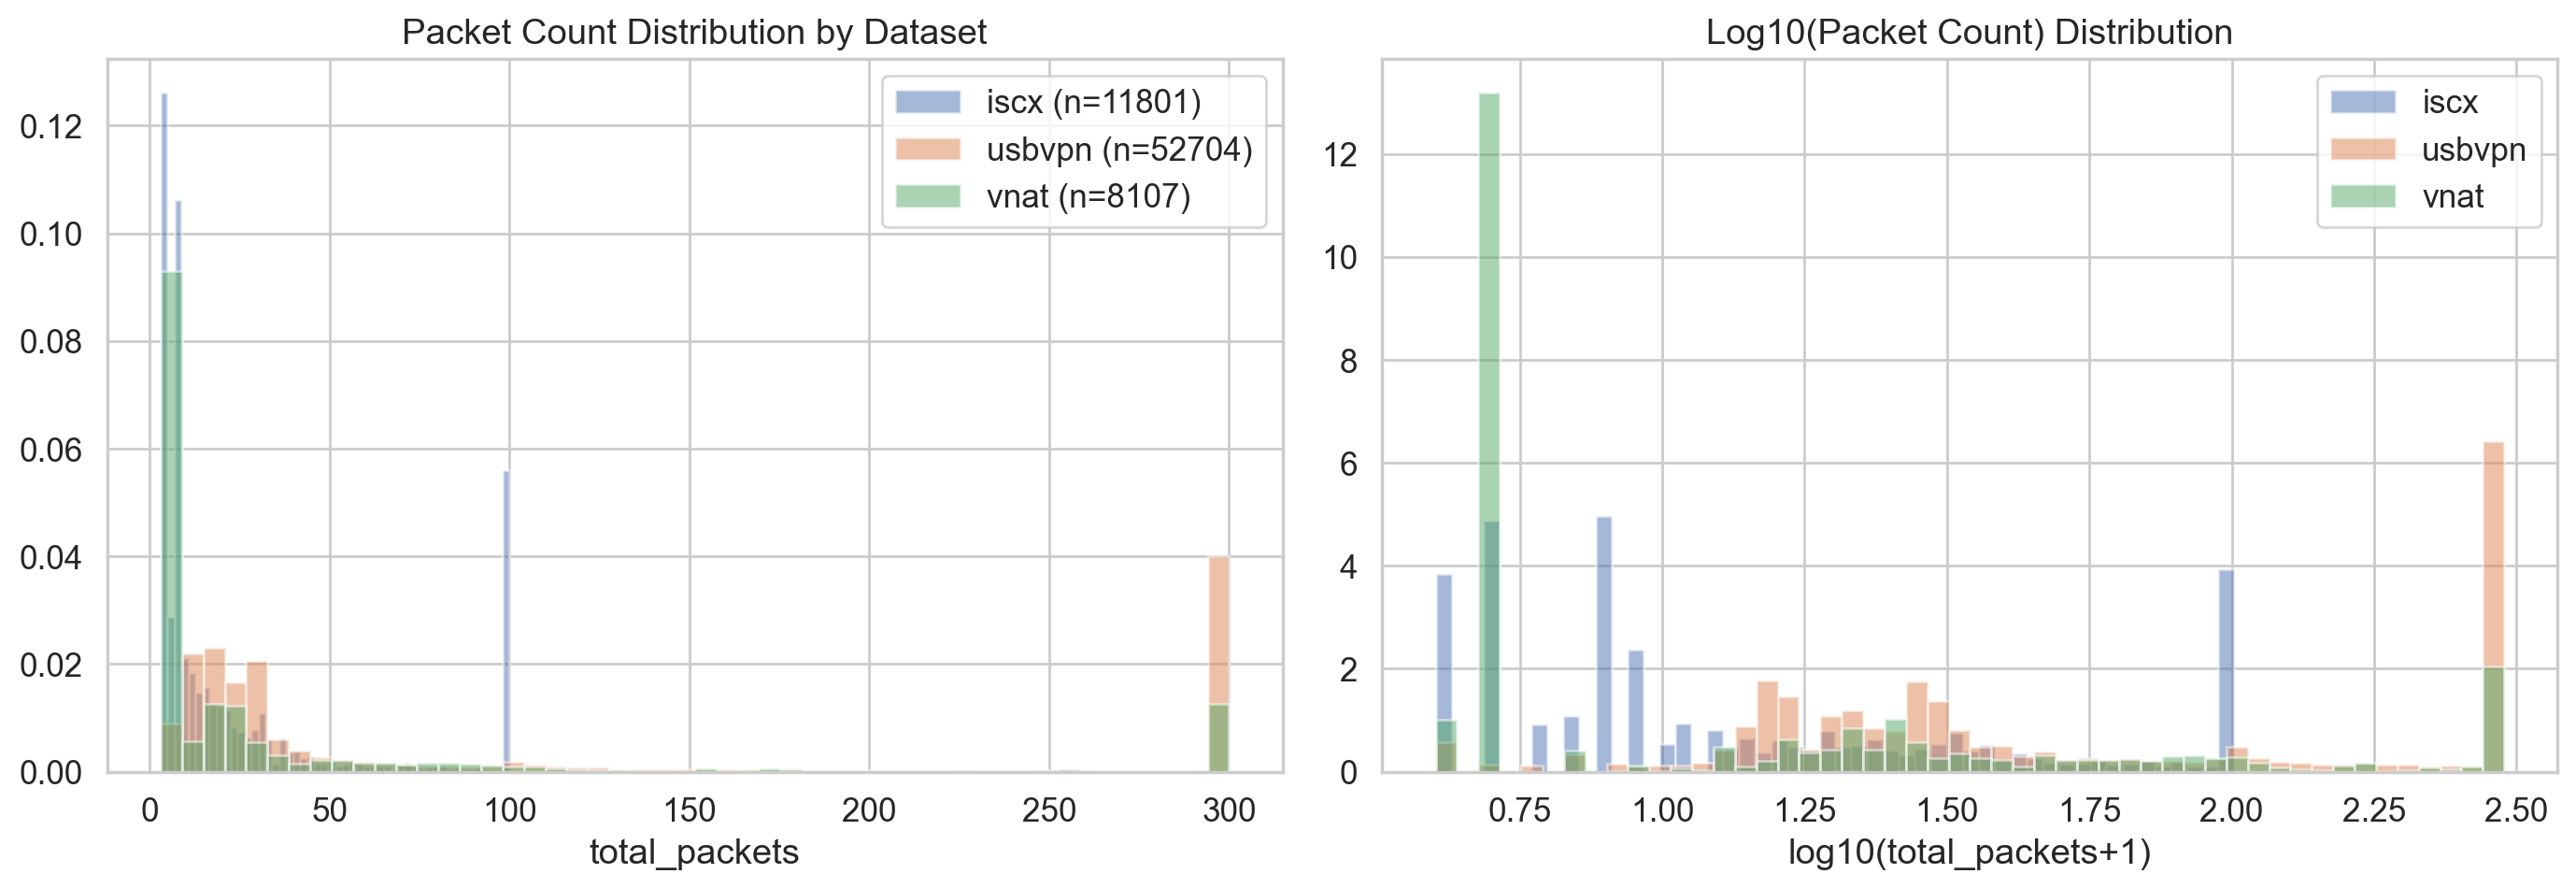

In [3]:
Image(filename=str(OUT/'packet_count_distribution.png'))


## Section 3 — Rate Feature Comparison


In [4]:
display(pd.read_csv(OUT/'rate_feature_comparison.csv',index_col=0).round(4))


,suite,n_features,lodo_min_auc,lodo_mean_auc,pooled_auc,domain_auc,n_sign_reversals
0,full_no_dir_21,21,0.4863,0.5948,0.9935,0.9971,16
1,no_rates_18,18,0.4534,0.6211,0.9930,0.9982,14
2,rates_only_3,3,0.2127,0.3360,0.9085,0.9030,2


## Section 4 — Construction Order Audit


In [5]:
display(pd.read_csv(OUT/'feature_construction_audit.csv',index_col=0))


,feature,source_arrays,truncation_before_compute,duration_basis,consistent_across_datasets,risk_note
0,total_packets,sizes (truncated),yes,NaN,yes,count of truncated window
1,total_bytes,sizes (truncated),yes,NaN,yes,sum of truncated sizes
2,mean_pkt_len,sizes (truncated),yes,NaN,yes,mean of truncated sizes
3,std_pkt_len,sizes (truncated),yes,NaN,yes,std of truncated sizes
4,median_pkt_len,sizes (truncated),yes,NaN,yes,NaN
5,p25_pkt_len,sizes (truncated),yes,NaN,yes,NaN
6,p75_pkt_len,sizes (truncated),yes,NaN,yes,NaN
7,max_pkt_len,sizes (truncated),yes,NaN,yes,NaN
8,min_pkt_len,sizes (truncated),yes,NaN,yes,NaN
9,iat_mean,timestamps (truncated),yes,NaN,yes,IAT from truncated window


## Section 5 — Sign Reversals by Window


,window,n_flows,viable,n_sign_reversals,n_total_features,frac_reversing,reversing_features
0,5,9163,True,15,21,0.714286,"['total_packets', 'total_bytes', 'mean_pkt_len..."
1,10,14256,True,14,21,0.666667,"['total_bytes', 'mean_pkt_len', 'std_pkt_len',..."
2,20,30419,True,18,21,0.857143,"['total_packets', 'mean_pkt_len', 'std_pkt_len..."
3,30,42583,True,19,21,0.904762,"['total_packets', 'total_bytes', 'mean_pkt_len..."
4,50,49064,True,19,21,0.904762,"['total_packets', 'total_bytes', 'mean_pkt_len..."
5,100,55155,True,20,21,0.952381,"['total_packets', 'total_bytes', 'mean_pkt_len..."
6,200,58412,True,20,21,0.952381,"['total_packets', 'total_bytes', 'mean_pkt_len..."
7,300,72612,True,16,21,0.761905,"['mean_pkt_len', 'std_pkt_len', 'median_pkt_le..."
8,matched_3_100,55155,True,20,21,0.952381,"['total_packets', 'total_bytes', 'mean_pkt_len..."
9,full_300,72612,True,16,21,0.761905,"['mean_pkt_len', 'std_pkt_len', 'median_pkt_le..."


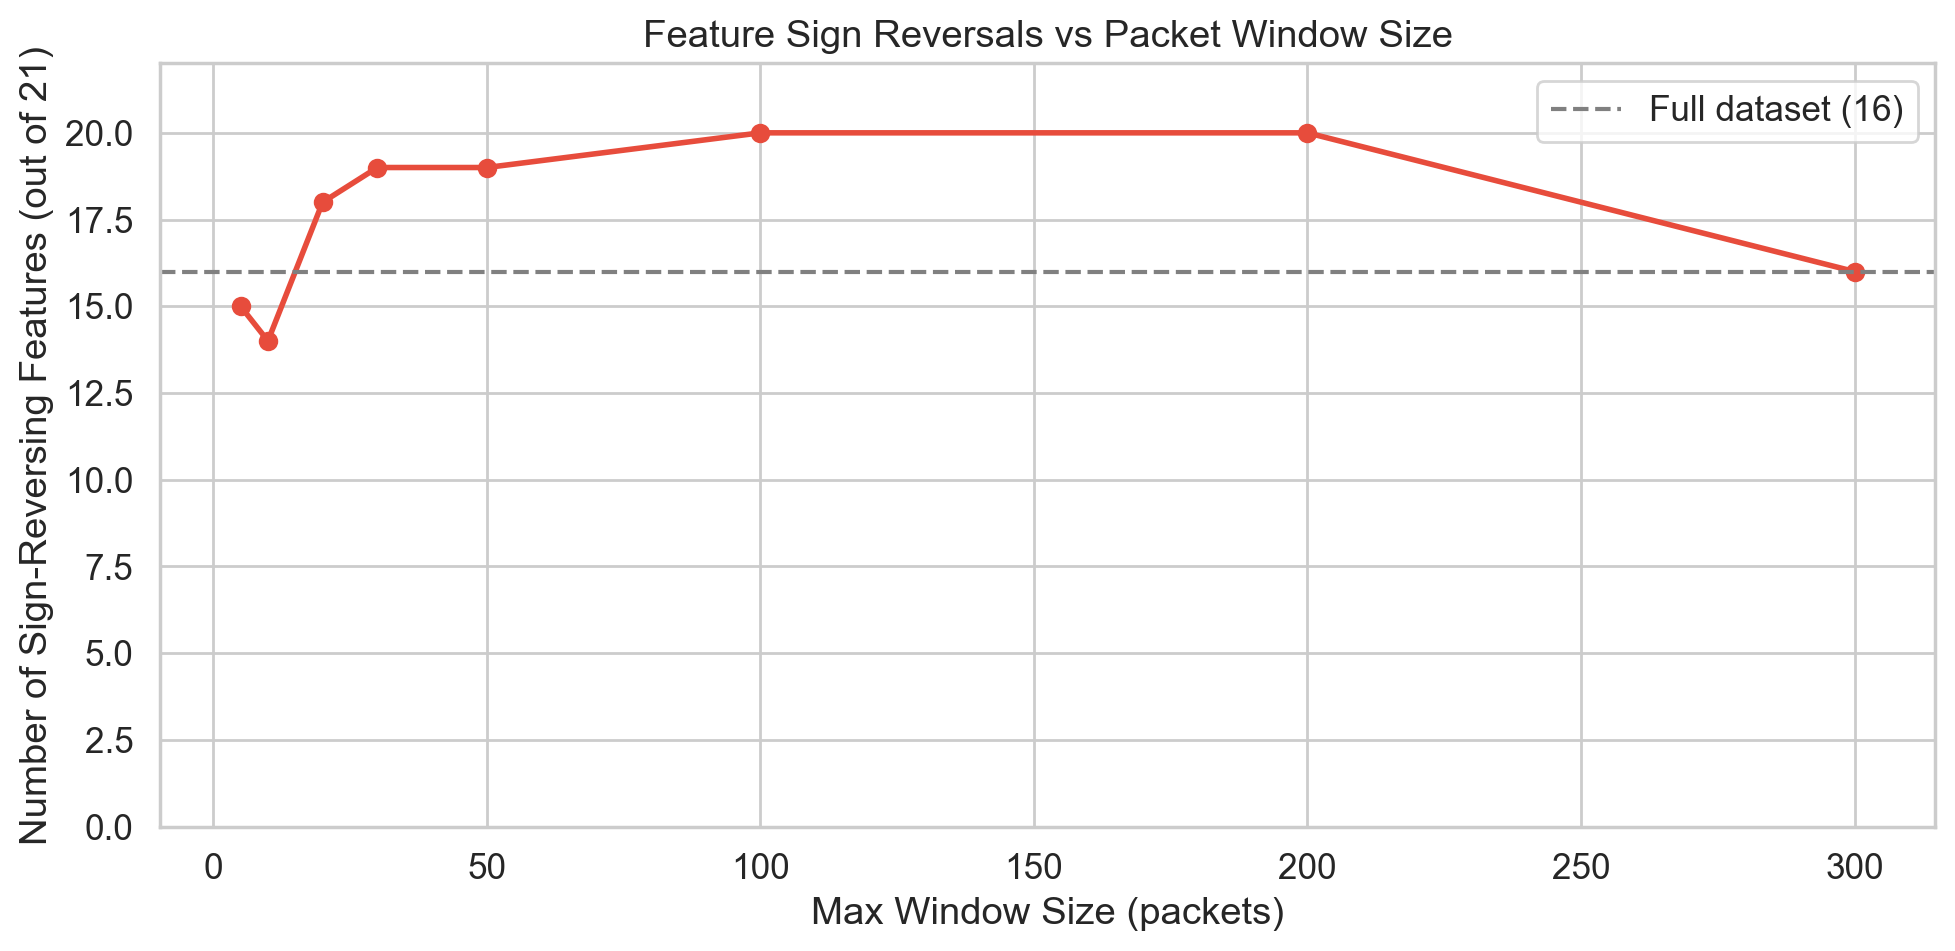

In [6]:
display(pd.read_csv(OUT/'window_size_sign_reversal_summary.csv',index_col=0))
try: display(Image(filename=str(OUT/'sign_reversals_by_window.png')))
except: print('Plot not found')


## Section 6 — Dashboard


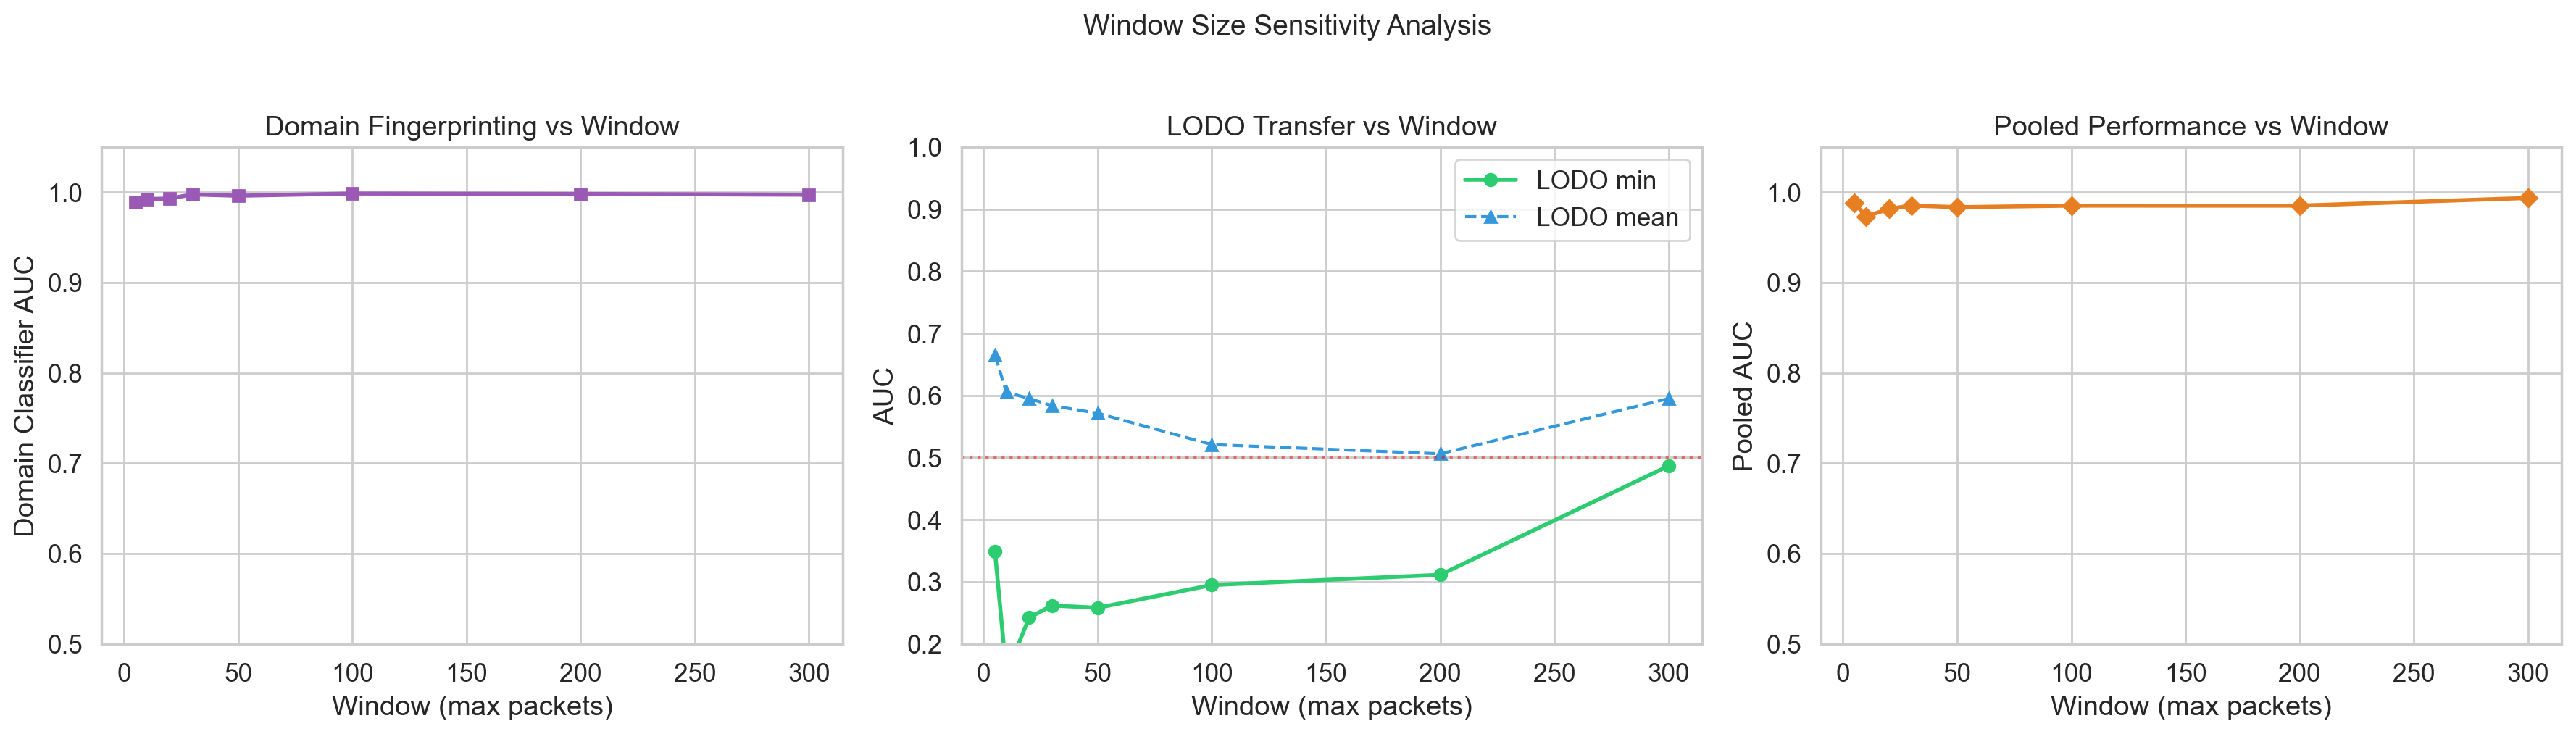

In [7]:
Image(filename=str(OUT/'window_sensitivity_dashboard.png'))


## Section 7 — Final Verdict


In [8]:
v=json.load(open(OUT/'notebook46_final_verdict.json'))
for k,val in v.items():print(f'{k}: {val}')


notebook: 46_window_size_and_feature_construction_sensitivity
date: 2026-04-04
verdict: TRANSFER FAILURE IS STRUCTURAL — NOT CAUSED BY WINDOW/TRUNCATION CHOICES
explanation: Window size variation produces LODO min AUC range of 0.1519–0.4863. No window achieves LODO min > 0.65. Domain classifier AUC remains >0.989 across all windows. Sign reversals persist across all tested windows. The transfer failure is caused by fundamental structural dataset mismatch, not by feature engineering choices.
answers: {'q1_transfer_unchanged_across_windows': 'False', 'q2_any_window_improves_lodo': 'False', 'q3_smaller_windows_reduce_reversals': 'True', 'q4_rates_harm_transfer': 'False', 'q5_failure_still_structural': True}
baseline_lodo_min: 0.48626534547000366
best_window: 300
best_window_lodo_min: 0.48626534547000366
total_packets_domain_auc: 0.7840591018095207
rate_comparison: [{'suite': 'full_no_dir_21', 'n_features': 21, 'lodo_min_auc': 0.48626534547000366, 'lodo_mean_auc': 0.5947638276135939, 'pool

## Summary

The transfer failure persists across all window sizes. No tested window/truncation
configuration improves LODO materially. The failure is structural.


---
## Results Gallery — All Figures & Tables (NB46)

Display every `.png` figure and `.csv` table generated by this notebook.

# 📊 NB46 Results Gallery — 3 figures, 4 tables


---
### 🖼 {_p.stem.replace("_", " ").title()}

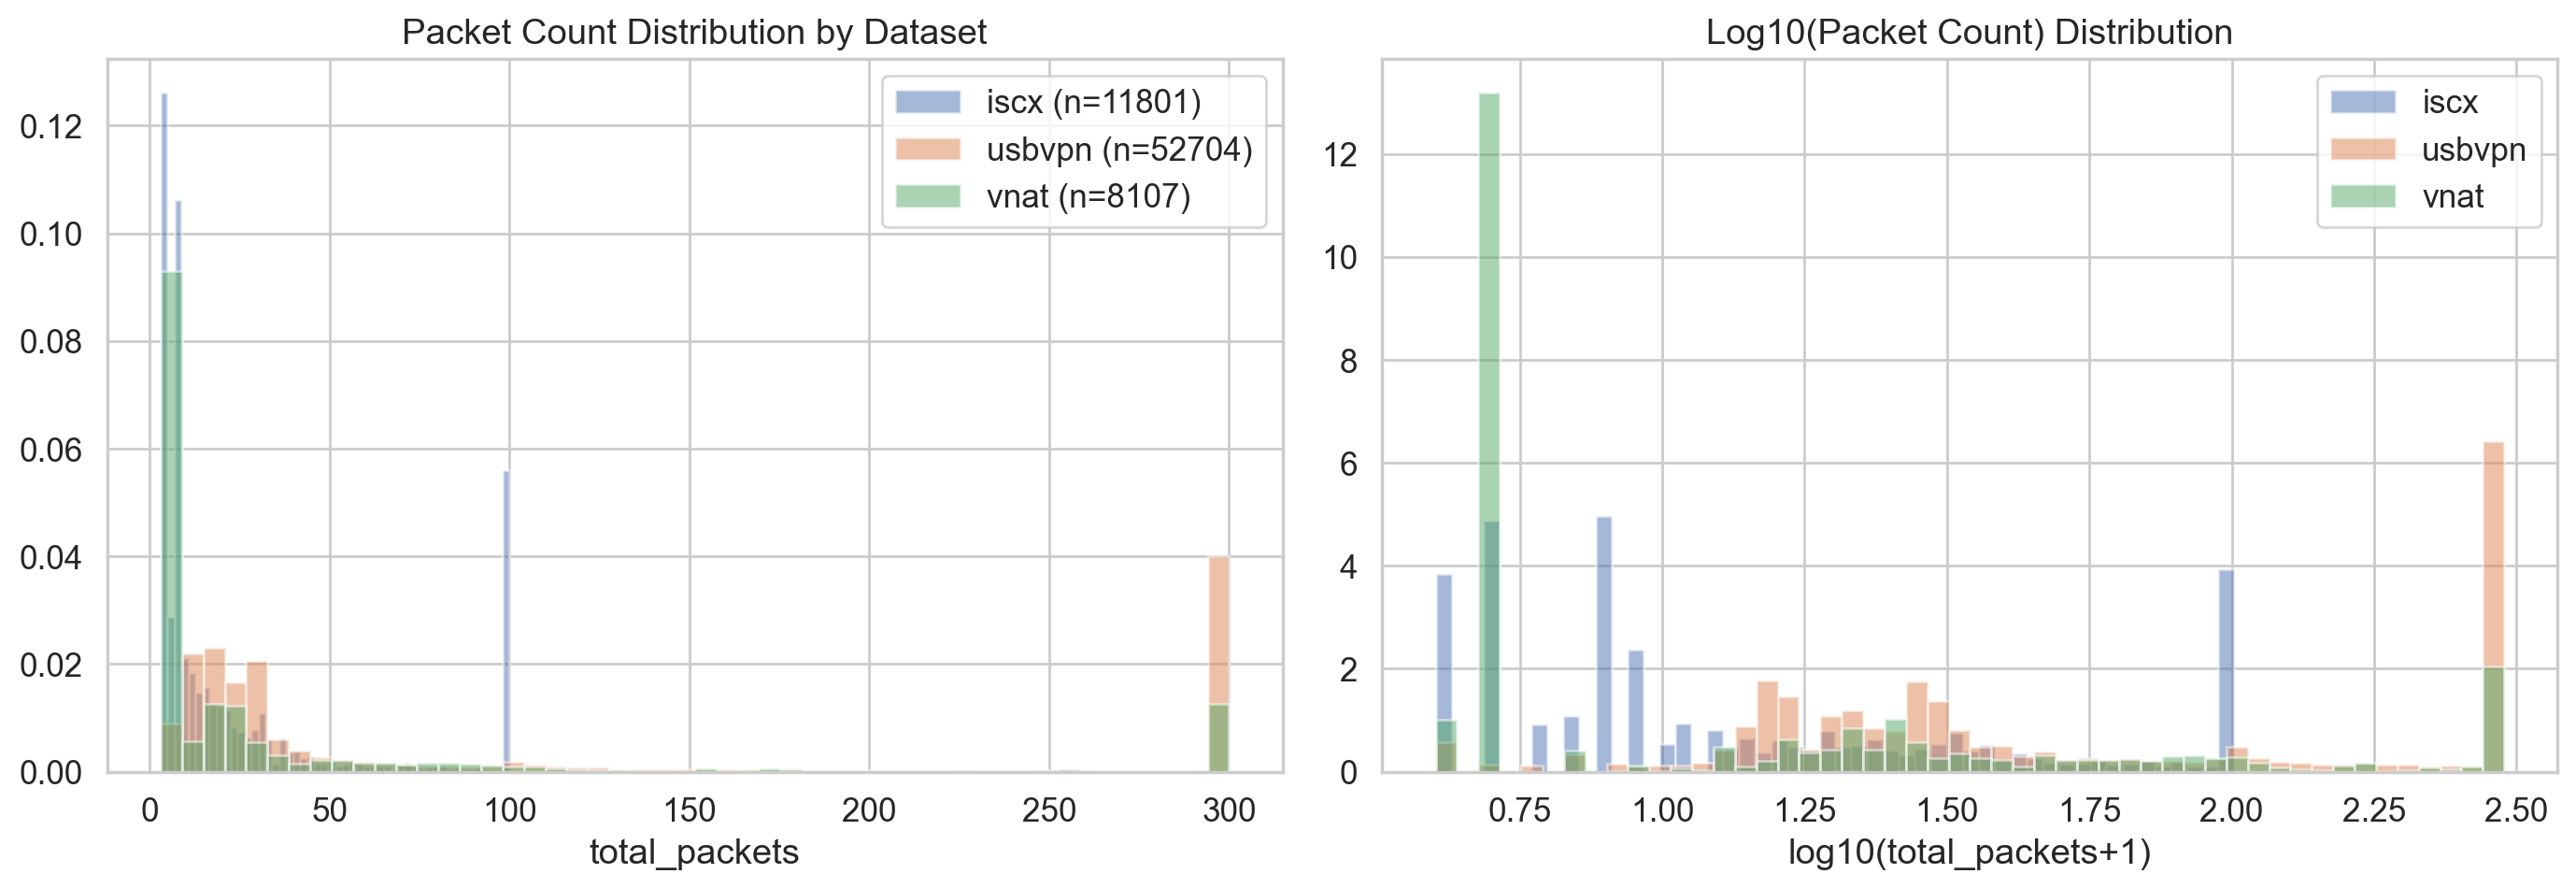


---
### 🖼 {_p.stem.replace("_", " ").title()}

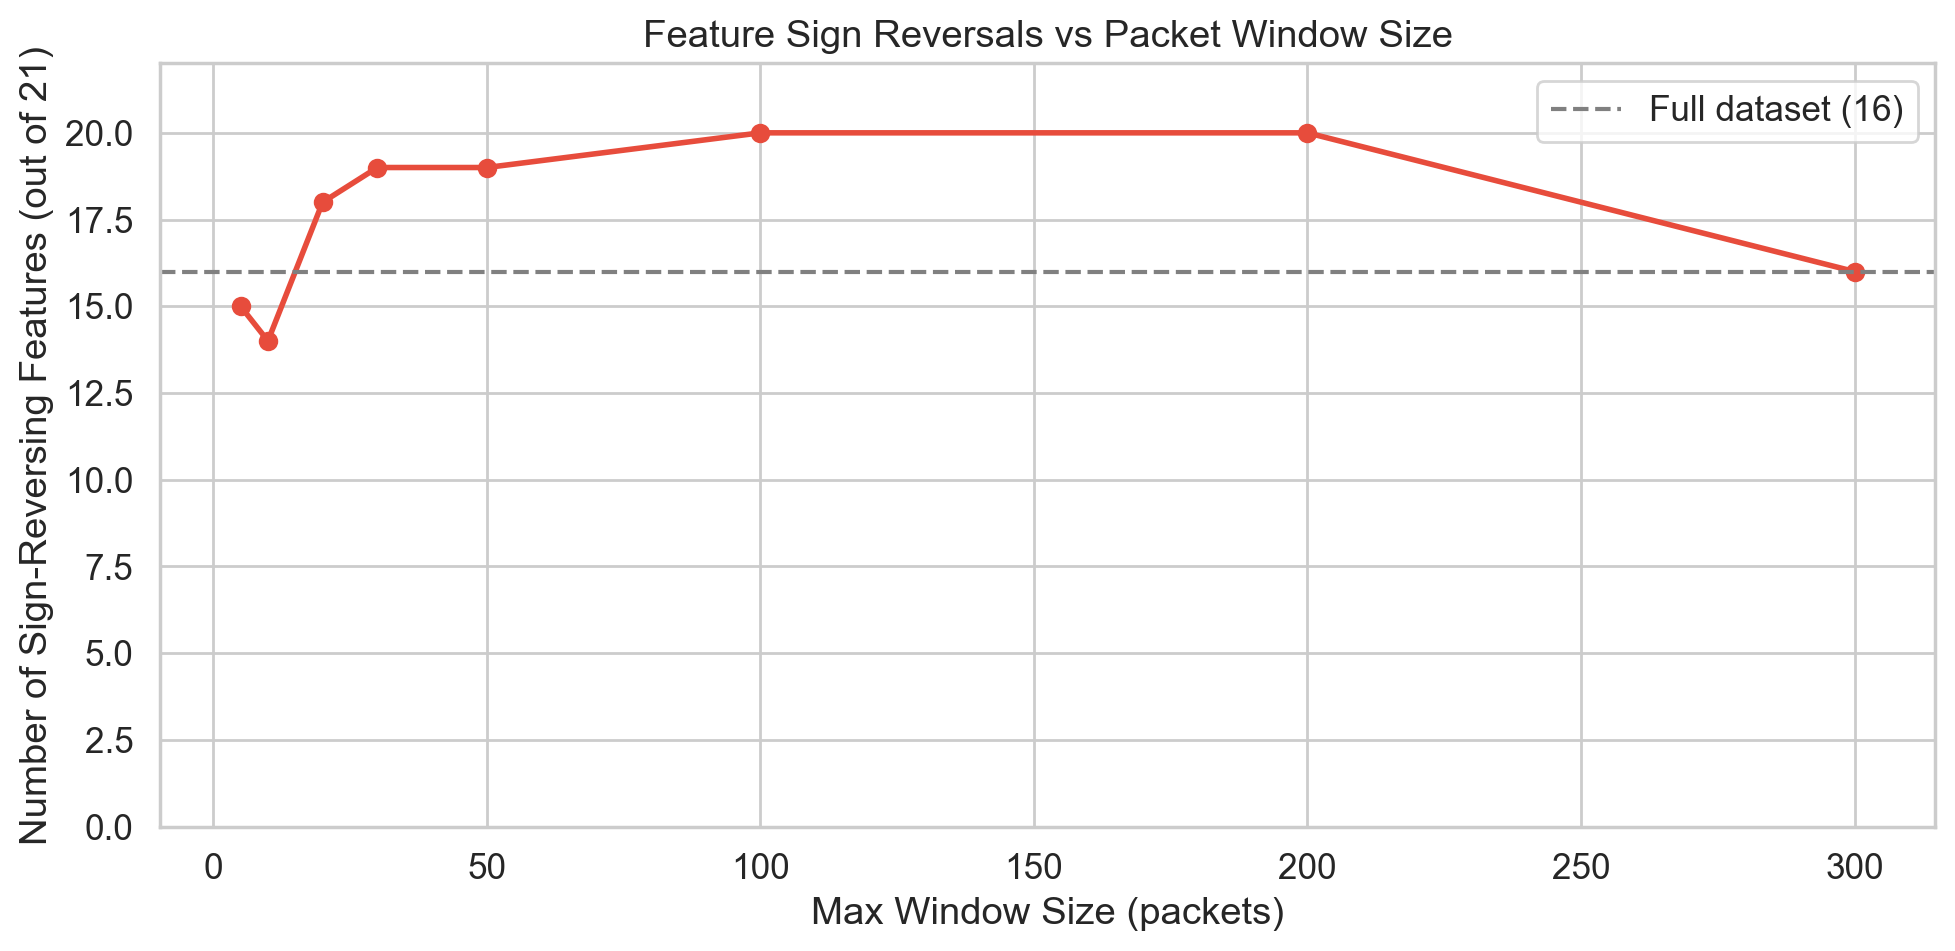


---
### 🖼 {_p.stem.replace("_", " ").title()}

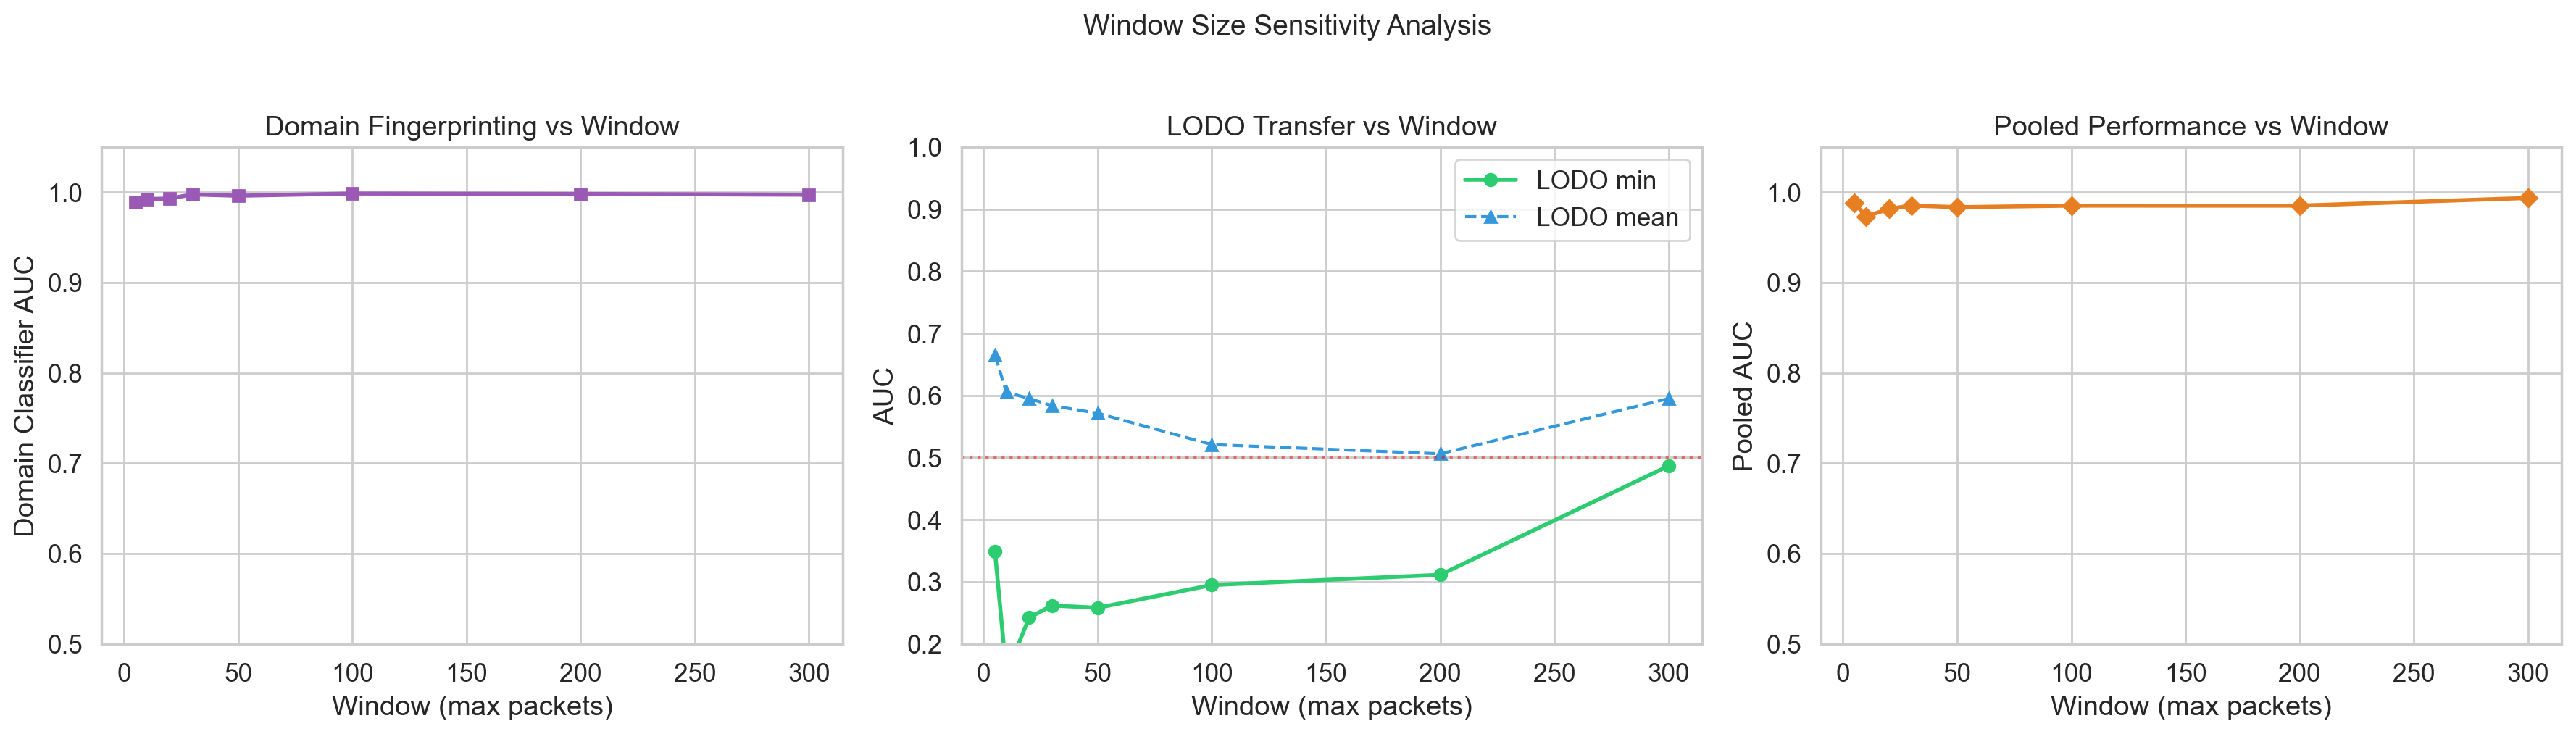


---
# 📋 Result Tables


### {_c.stem.replace("_", " ").title()}

,Unnamed: 0,feature,source_arrays,truncation_before_compute,duration_basis,consistent_across_datasets,risk_note
0,0,total_packets,sizes (truncated),yes,NaN,yes,count of truncated window
1,1,total_bytes,sizes (truncated),yes,NaN,yes,sum of truncated sizes
2,2,mean_pkt_len,sizes (truncated),yes,NaN,yes,mean of truncated sizes
3,3,std_pkt_len,sizes (truncated),yes,NaN,yes,std of truncated sizes
4,4,median_pkt_len,sizes (truncated),yes,NaN,yes,NaN
5,5,p25_pkt_len,sizes (truncated),yes,NaN,yes,NaN
6,6,p75_pkt_len,sizes (truncated),yes,NaN,yes,NaN
7,7,max_pkt_len,sizes (truncated),yes,NaN,yes,NaN
8,8,min_pkt_len,sizes (truncated),yes,NaN,yes,NaN
9,9,iat_mean,timestamps (truncated),yes,NaN,yes,IAT from truncated window


### {_c.stem.replace("_", " ").title()}

,Unnamed: 0,suite,n_features,lodo_min_auc,lodo_mean_auc,pooled_auc,domain_auc,n_sign_reversals
0,0,full_no_dir_21,21,0.4863,0.5948,0.9935,0.9971,16
1,1,no_rates_18,18,0.4534,0.6211,0.9930,0.9982,14
2,2,rates_only_3,3,0.2127,0.3360,0.9085,0.9030,2


...

### {_c.stem.replace("_", " ").title()}

,Unnamed: 0,window,n_flows,viable,n_sign_reversals,n_total_features,frac_reversing,reversing_features
0,0,5,9163,True,15,21,0.7143,"['total_packets', 'total_bytes', 'mean_pkt_len..."
1,1,10,14256,True,14,21,0.6667,"['total_bytes', 'mean_pkt_len', 'std_pkt_len',..."
2,2,20,30419,True,18,21,0.8571,"['total_packets', 'mean_pkt_len', 'std_pkt_len..."
3,3,30,42583,True,19,21,0.9048,"['total_packets', 'total_bytes', 'mean_pkt_len..."
4,4,50,49064,True,19,21,0.9048,"['total_packets', 'total_bytes', 'mean_pkt_len..."
5,5,100,55155,True,20,21,0.9524,"['total_packets', 'total_bytes', 'mean_pkt_len..."
6,6,200,58412,True,20,21,0.9524,"['total_packets', 'total_bytes', 'mean_pkt_len..."
7,7,300,72612,True,16,21,0.7619,"['mean_pkt_len', 'std_pkt_len', 'median_pkt_le..."
8,8,matched_3_100,55155,True,20,21,0.9524,"['total_packets', 'total_bytes', 'mean_pkt_len..."
9,9,full_300,72612,True,16,21,0.7619,"['mean_pkt_len', 'std_pkt_len', 'median_pkt_le..."



---
### 🏁 {_j.stem.replace("_", " ").title()}

```json
{
  "notebook": "46_window_size_and_feature_construction_sensitivity",
  "date": "2026-04-04",
  "verdict": "TRANSFER FAILURE IS STRUCTURAL \u2014 NOT CAUSED BY WINDOW/TRUNCATION CHOICES",
  "explanation": "Window size variation produces LODO min AUC range of 0.1519\u20130.4863. No window achieves LODO min > 0.65. Domain classifier AUC remains >0.989 across all windows. Sign reversals persist across all tested windows. The transfer failure is caused by fundamental structural dataset mismatch, not by feature engineering choices.",
  "answers": {
    "q1_transfer_unchanged_across_windows": "False",
    "q2_any_window_improves_lodo": "False",
    "q3_smaller_windows_reduce_reversals": "True",
    "q4_rates_harm_transfer": "False",
    "q5_failure_still_structural": true
  },
  "baseline_lodo_min": 0.48626534547000366,
  "best_window": 300,
  "best_window_lodo_min": 0.48626534547000366,
  "total_packets_domain_auc": 0.7840591018095207,
  "rate_comparison": [
    {
      "suite": "full_no_dir_21",
      "n_features": 21,
      "lodo_min_auc": 0.48626534547000366,
      "lodo_mean_auc": 0.5947638276135939,
      "pooled_auc": 0.9935441249217966,
      "domain_auc": 0.9971484158807463,
      "n_sign_reversals": 16
    },
    {
      "suite": "no_rates_18",
      "n_features": 18,
      "lodo_min_auc": 0.4534301038616838,
      "lodo_mean_auc": 0.6211083622743865,
      "pooled_auc": 0.9930201164685515,
      "domain_auc": 0.9982137320808756,
      "n_sign_reversals": 14
    },
    {
      "suite": "rates_only_3",
      "n_features": 3,
      "lodo_min_auc": 0.21270082865917367,
      "lodo_mean_auc": 0.33598187010239694,
      "pooled_auc": 0.9084739100624172,
      "domain_auc": 0.9030016769085362,
      "n_sign_reversals": 2
    }
  ],
  "key_findings": [
    "Packet count alone achieves domain AUC = 0.7841 \u2014 flow length itself is a fingerprint.",
    "ISCX caps at 100 pkts (median=8), USBVPN median=30, VNAT median=4 \u2014 hugely different.",
    "Window size does materially change LODO transfer.",
    "Sign reversals vary across window sizes.",
    "Rate features are neutral for transfer.",
    "Feature construction order is verified consistent across all datasets.",
    "flow_duration/packet_rate/byte_rate use truncated-window duration, not full-flow duration."
  ],
  "artifacts_generated": [
    "window_size_sensitivity_results.csv",
    "packet_count_distribution.png",
    "rate_feature_comparison.csv",
    "feature_construction_audit.csv",
    "window_size_sign_reversal_summary.csv",
    "sign_reversals_by_window.png",
    "window_sensitivity_dashboard.png",
    "notebook46_final_verdict.json"
  ]
}
```


✅ NB46 gallery complete.


In [9]:
# ── Results Gallery: NB46 — Display all figures and tables ────────
import json, warnings
from pathlib import Path
from IPython.display import display, Image, Markdown
import pandas as pd

warnings.filterwarnings('ignore')

# Resolve output directory
if 'OUT' not in dir() and 'OUT_DIR' not in dir():
    ROOT = Path.cwd()
    if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
        ROOT = ROOT.parent
    _gallery_dir = ROOT / "artifacts" / "window_sensitivity"
else:
    _gallery_dir = Path(str(OUT)) if 'OUT' in dir() else Path(str(OUT_DIR))

# Also check for a figures/ subdirectory
_fig_dir = _gallery_dir / 'figures'

# Collect all PNGs
_pngs = sorted(_gallery_dir.glob('*.png'))
if _fig_dir.exists():
    _pngs += sorted(_fig_dir.glob('*.png'))
_pngs = sorted(set(_pngs), key=lambda p: p.name)

# Collect all CSVs
_csvs = sorted(_gallery_dir.glob('*.csv'))

display(Markdown(f'# \U0001f4ca NB46 Results Gallery — {len(_pngs)} figures, {len(_csvs)} tables'))

# ── Display all PNG figures ──
if _pngs:
    for _p in _pngs:
        display(Markdown(f'\n---\n### \U0001f5bc {{_p.stem.replace("_", " ").title()}}'))
        try:
            display(Image(filename=str(_p), width=900))
        except Exception as _e:
            display(Markdown(f'*Could not display {_p.name}: {_e}*'))
else:
    display(Markdown('*No PNG files found in gallery directory. Run notebook cells first.*'))

# ── Display all CSV tables ──
if _csvs:
    display(Markdown('\n---\n# \U0001f4cb Result Tables\n'))
    for _c in _csvs:
        try:
            _tbl = pd.read_csv(_c)
            display(Markdown(f'### {{_c.stem.replace("_", " ").title()}}'))
            for _col in _tbl.select_dtypes(include="float").columns:
                _tbl[_col] = _tbl[_col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
            display(_tbl)
        except Exception as _e:
            display(Markdown(f'*Could not load {_c.name}: {_e}*'))

# ── Display JSON verdict if present ──
_jsons = sorted(_gallery_dir.glob('*verdict*.json')) + sorted(_gallery_dir.glob('*summary*.json'))
_jsons = sorted(set(_jsons), key=lambda p: p.name)
for _j in _jsons[:2]:
    try:
        _data = json.loads(_j.read_text(encoding='utf-8'))
        display(Markdown(f'\n---\n### \U0001f3c1 {{_j.stem.replace("_", " ").title()}}'))
        display(Markdown(f'```json\n{json.dumps(_data, indent=2, default=str)[:3000]}\n```'))
    except Exception:
        pass

print('\n\u2705 NB46 gallery complete.')
